<a href="https://colab.research.google.com/github/siyal-sss/leukemia-biomarker-discovery/blob/main/Leukemia_gene.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
from google.colab import files

uploaded = files.upload()

Saving data_set_ALL_AML_independent.csv to data_set_ALL_AML_independent (4).csv


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Load the dataset (Update path if uploaded to Google Drive or Colab session storage)
file_path = 'data_set_ALL_AML_independent.csv'
df = pd.read_csv(file_path)

# 2. Inspect the raw data shape
print(f"Original Data Shape: {df.shape}")

# 3. Separate gene metadata from expression values
gene_info = df[['Gene Description', 'Gene Accession Number']]
expression_data = df.drop(columns=['Gene Description', 'Gene Accession Number'])

# 4. Filter out the 'call' columns (A/P/M flags) to keep only numeric expression levels
numeric_cols = [col for col in expression_data.columns if 'call' not in col]
expression_numeric = expression_data[numeric_cols]

# 5. Transpose so rows = patient samples, columns = genes
X = expression_numeric.T
X.columns = gene_info['Gene Accession Number']
X.index = X.index.astype(int) # Ensure sample IDs are integers

print(f"Cleaned Feature Matrix Shape (Samples x Genes): {X.shape}")
X.head()

Original Data Shape: (7129, 70)
Cleaned Feature Matrix Shape (Samples x Genes): (34, 7129)


Gene Accession Number,AFFX-BioB-5_at,AFFX-BioB-M_at,AFFX-BioB-3_at,AFFX-BioC-5_at,AFFX-BioC-3_at,AFFX-BioDn-5_at,AFFX-BioDn-3_at,AFFX-CreX-5_at,AFFX-CreX-3_at,AFFX-BioB-5_st,...,U48730_at,U58516_at,U73738_at,X06956_at,X16699_at,X83863_at,Z17240_at,L49218_f_at,M71243_f_at,Z78285_f_at
39,-342,-200,41,328,-224,-427,-656,-292,137,-144,...,277,1023,67,214,-135,1074,475,48,168,-70
40,-87,-248,262,295,-226,-493,367,-452,194,162,...,83,529,-295,352,-67,67,263,-33,-33,-21
42,22,-153,17,276,-211,-250,55,-141,0,500,...,413,399,16,558,24,893,297,6,1971,-42
47,-243,-218,-163,182,-289,-268,-285,-172,52,-134,...,174,277,6,81,2,722,170,0,510,-73
48,-130,-177,-28,266,-170,-326,-222,-93,10,159,...,233,643,51,450,-46,612,370,29,333,-19


In [9]:
# Simulating the biological labels (ALL vs AML) based on standard dataset splits
# Usually, samples 39-56 are ALL and 57-72 are AML (with a few exceptions)
y = np.where(X.index <= 56, 'ALL', 'AML')

print("Class Distribution:")
print(pd.Series(y).value_counts())

Class Distribution:
ALL    18
AML    16
Name: count, dtype: int64


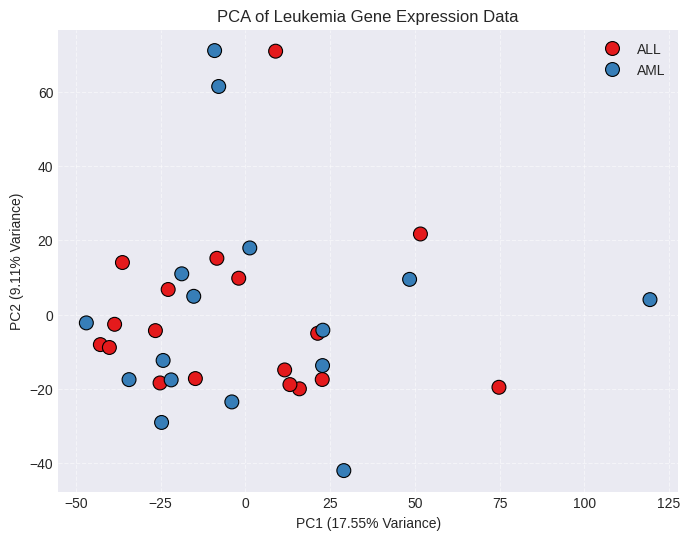

In [10]:
# Standardize the data before PCA
from sklearn.preprocessing import StandardScaler
X_scaled = StandardScaler().fit_transform(X)

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plotting the clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette='Set1', s=100, edgecolor='k')
plt.title('PCA of Leukemia Gene Expression Data')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% Variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% Variance)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

--- Classification Report ---
              precision    recall  f1-score   support

         ALL       0.60      0.50      0.55         6
         AML       0.50      0.60      0.55         5

    accuracy                           0.55        11
   macro avg       0.55      0.55      0.55        11
weighted avg       0.55      0.55      0.55        11



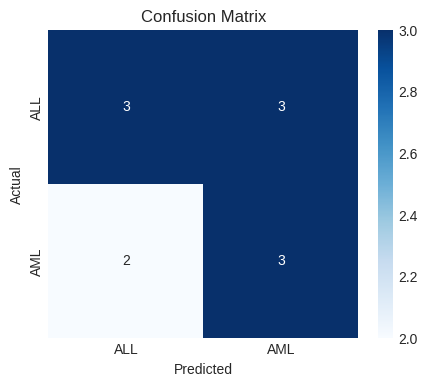

In [11]:
# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Initialize and train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions
y_pred = rf_model.predict(X_test)

# Evaluation metrics
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

# Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['ALL', 'AML'], yticklabels=['ALL', 'AML'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

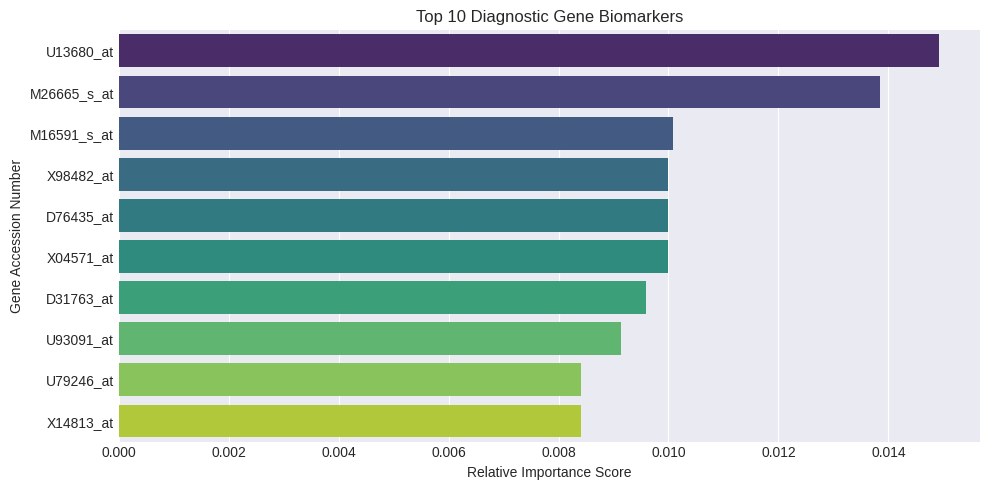

,Gene ID,Description,Importance
0,U13680_at,LDHC Lactate dehydrogenase C,0.014922
1,M26665_s_at,HISTATIN 3 PRECURSOR,0.013840
2,M16591_s_at,HCK Hemopoietic cell kinase,0.010080
3,X98482_at,GB DEF = TNNT2 gene exon 11,0.010000
4,D76435_at,Zic protein,0.010000
5,X04571_at,EGF Epidermal growth factor,0.010000
6,D31763_at,KIAA0065 gene; partial cds,0.009597
7,U93091_at,GB DEF = Toll protein homolog mRNA and LINE-1 ...,0.009134
8,U79246_at,Clone 23799 mRNA sequence,0.008403
9,X14813_at,ACAA Acetyl-Coenzyme A acyltransferase (peroxi...,0.008403


In [12]:
# Extract feature importances
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

# Map back to Gene Descriptions
top_n = 10
top_genes = []

for i in range(top_n):
    gene_id = X.columns[indices[i]]
    gene_desc = gene_info[gene_info['Gene Accession Number'] == gene_id]['Gene Description'].values[0]
    top_genes.append({'Gene ID': gene_id, 'Description': gene_desc, 'Importance': importances[indices[i]]})

top_genes_df = pd.DataFrame(top_genes)

# Plot Top 10 Features
plt.figure(figsize=(10, 5))
sns.barplot(data=top_genes_df, x='Importance', y='Gene ID', palette='viridis')
plt.title('Top 10 Diagnostic Gene Biomarkers')
plt.xlabel('Relative Importance Score')
plt.ylabel('Gene Accession Number')
plt.tight_layout()
plt.show()

# Display the descriptions table
top_genes_df

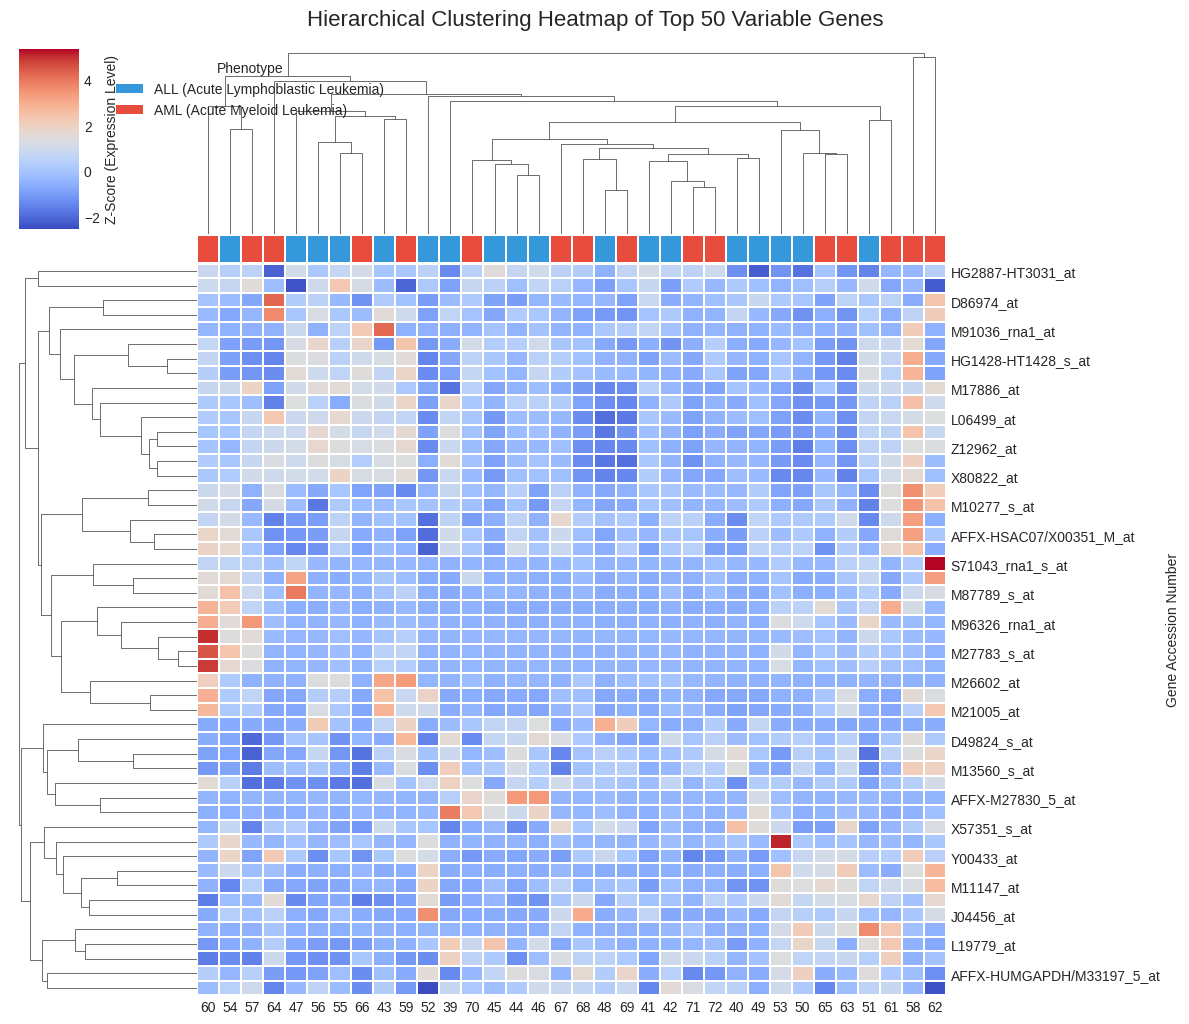

In [13]:
# 1. Calculate variance for each gene across all samples
gene_variances = X.var(axis=0)

# 2. Select the top 50 most variable genes
top_50_genes = gene_variances.nlargest(50).index
X_top_50 = X[top_50_genes]

# 3. Create a dataframe for plotting and scale the expression values (Z-score normalization)
# This centers the data so high expression is red/warm and low expression is blue/cool
from sklearn.preprocessing import StandardScaler
X_top_50_scaled = pd.DataFrame(
    StandardScaler().fit_transform(X_top_50),
    index=X.index,
    columns=top_50_genes
)

# 4. Map the diagnostic labels (ALL vs AML) to distinct colors for the sidebar
label_colors = pd.Series(y, index=X.index).map({'ALL': '#3498db', 'AML': '#e74c3c'})

# 5. Plot the Clustermap
g = sns.clustermap(
    X_top_50_scaled.T, # Transpose to put genes on rows and patient samples on columns
    cmap='coolwarm',   # Classic genomic expression color palette
    col_colors=label_colors, # Adds a color bar highlighting ALL vs AML patients
    figsize=(12, 10),
    cbar_kws={'label': 'Z-Score (Expression Level)'},
    linewidths=0.1
)

# Add a title and legend for the phenotype bars
g.fig.suptitle('Hierarchical Clustering Heatmap of Top 50 Variable Genes', y=1.02, fontsize=16)

# Create custom legend for the patient phenotype color track
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#3498db', label='ALL (Acute Lymphoblastic Leukemia)'),
    Patch(facecolor='#e74c3c', label='AML (Acute Myeloid Leukemia)')
]
plt.legend(handles=legend_elements, bbox_to_anchor=(1.4, 1), loc='upper left', title='Phenotype')

plt.show()